# Importing Libraries

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import string
import warnings
warnings.filterwarnings('ignore')

## Load and inspect data

In [2]:
df = pd.read_csv("C:/Users/admin/Documents/prog for data(PDAN8411)/POE/product_reviews.csv")

In [3]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 5)

First 5 rows:


,Text,Label,Window,User Name,User ID
0,"It works as described, no major issues.",Neutral,Flipkart,Arjun Singh,U1001
1,Customer service was unhelpful and rude.,Negative,Flipkart,Vikram Joshi,U1002
2,"Amazing quality, totally worth the price.",Positive,Flipkart,Ananya Roy,U1003
3,"I am very satisfied with my purchase, highly r...",Positive,Flipkart,Vikram Joshi,U1004
4,"I am disappointed, it did not meet my expectat...",Negative,Flipkart,Raj Verma,U1005


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Text           1000 non-null   object
 1   Label          1000 non-null   object
 2   Window         1000 non-null   object
 3   User Name      1000 non-null   object
 4   User ID        1000 non-null   object
 5   review_length  1000 non-null   int64 
 6   clean_text     1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [5]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Text         0
Label        0
Window       0
User Name    0
User ID      0
dtype: int64


# Exploratory data analysis (EDA)
what will be done in this section is class distribution, review length and words clouds to visualize dataset and gain more insights from it.


### Check for class distribution 

In [6]:
print("Class distribution:\n", df['Label'].value_counts())

Class distribution:
 Label
Neutral     344
Positive    344
Negative    312
Name: count, dtype: int64


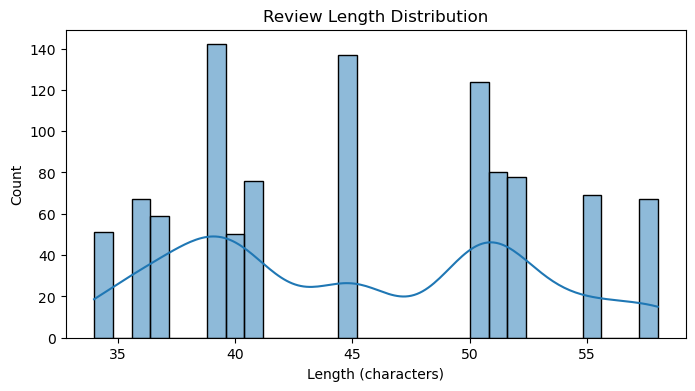

In [7]:
# Review length analysis
df['review_length'] = df['Text'].str.len()
plt.figure(figsize=(8,4))
sns.histplot(df['review_length'], bins=30, kde=True)
plt.title('Review Length Distribution')
plt.xlabel('Length (characters)')
plt.show()

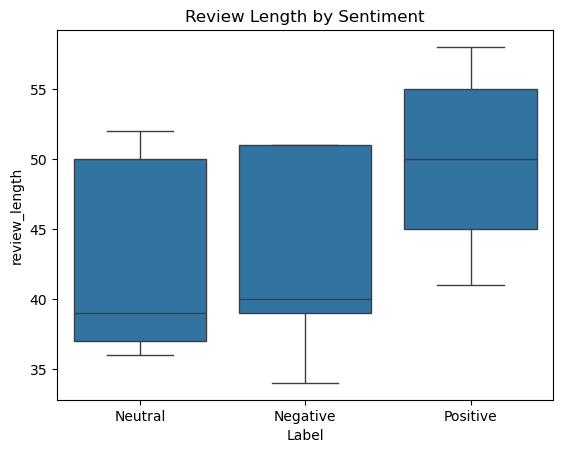

In [8]:
# Boxplot by sentiment
sns.boxplot(x='Label', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.show()

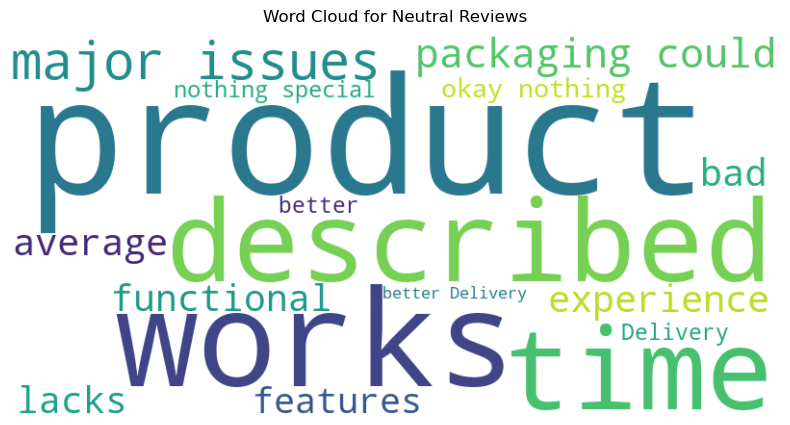

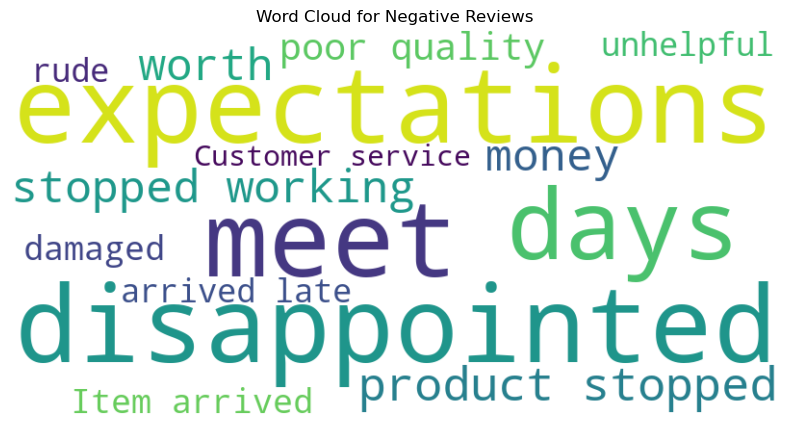

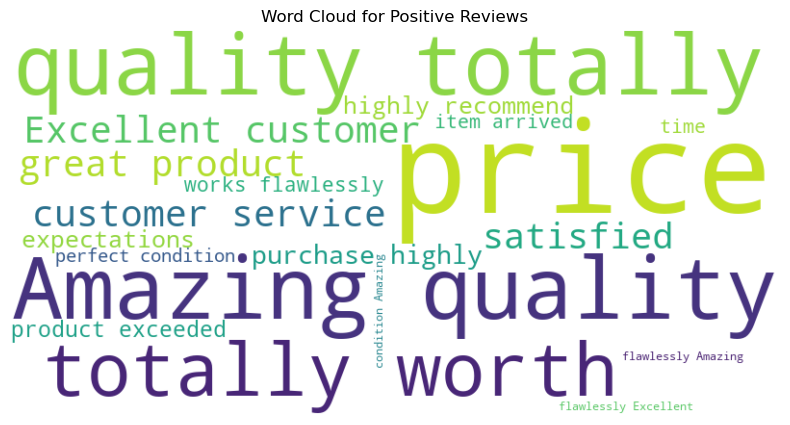

In [9]:
# Word clouds per class
stop_words = set(stopwords.words('english'))
for label in df['Label'].unique():
    text = ' '.join(df[df['Label']==label]['Text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label} Reviews')
    plt.axis('off')
    plt.show()

## Text Preprocessing

In [10]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['Text'].apply(clean_text)

In [11]:
# Encode target labels (alphabetical: Negative=0, Neutral=1, Positive=2)
le = LabelEncoder()
y = le.fit_transform(df['Label'])
print("Encoded classes:", le.classes_)

Encoded classes: ['Negative' 'Neutral' 'Positive']


## Feature Extraction
Here i will be converting text values into numerical features 

In [29]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
print("Feature matrix shape:", X.shape)
print("Feature matrix shape:", X.shape)
print("Top 20 feature names:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (1000, 96)
Feature matrix shape: (1000, 96)
Top 20 feature names: ['amazing' 'amazing quality' 'arrived' 'arrived late' 'arrived time'
 'average' 'average bad' 'bad' 'better' 'condition' 'could' 'could better'
 'customer' 'customer service' 'damaged' 'days' 'delivery' 'delivery time'
 'described' 'described major']


## Train/Test split 
will split data into training set which will be 80% of the set and testing set which will be 20% of set.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (800, 96) Test size: (200, 96)


## Model Selection 
using cross-validation to compare logistic regression, Naive Bayes, and SVM using 5-fold CV.

In [32]:
# compare the three classifiers with default parameters using 5‑fold CV.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42)
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: mean CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression: mean CV accuracy = 1.0000 (+/- 0.0000)
Naive Bayes: mean CV accuracy = 1.0000 (+/- 0.0000)
Linear SVM: mean CV accuracy = 1.0000 (+/- 0.0000)


In [33]:
# Choosing Logistic Regression as it performs best
best_model_name = max(cv_scores, key=cv_scores.get)
print(f"\nBest model: {best_model_name} with CV accuracy {cv_scores[best_model_name]:.4f}")


Best model: Logistic Regression with CV accuracy 1.0000


## Hyperparameter tuning 

In [34]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
base_lr = LogisticRegression(max_iter=1000, random_state=42)
grid = GridSearchCV(base_lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_lr = grid.best_estimator_

Best parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV accuracy: 1.0


## Model Evaluation
Evaluate the performance of the model using accuracy, classification report, confusion matrix on the test set

In [35]:
# Model Evaluation on Test Set
y_pred = best_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        62
     Neutral       1.00      1.00      1.00        69
    Positive       1.00      1.00      1.00        69

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



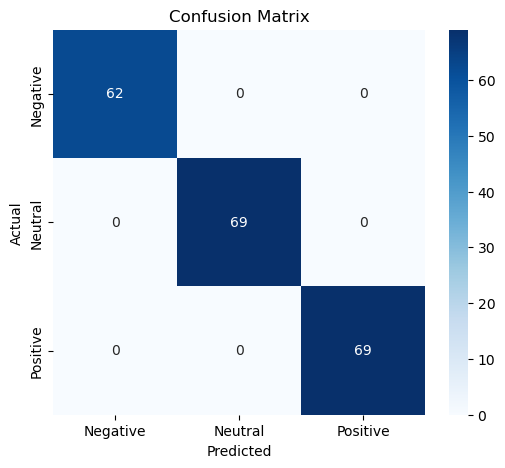

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Retraining
to test a different parameter for comparison.

In [37]:
model_default = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000, random_state=42)
model_default.fit(X_train, y_train)
y_pred_def = model_default.predict(X_test)
acc_def = accuracy_score(y_test, y_pred_def)
print(f"Accuracy with C=1.0: {acc_def:.4f}")

# Compare with the tuned model
print(f"Accuracy with tuned C={best_lr.C}: {accuracy:.4f}")

Accuracy with C=1.0: 1.0000
Accuracy with tuned C=0.01: 1.0000


## Predictive system
function to classify new reviews with confidence scores.

In [38]:
#predictive system
def predict_sentiment(review_text):
    """
    Predict sentiment (Positive, Neutral, Negative) from a review string.
    Returns label and confidence scores.
    """
    cleaned = clean_text(review_text)
    vector = tfidf.transform([cleaned])
    pred = best_lr.predict(vector)[0]
    prob = best_lr.predict_proba(vector)[0]
    return le.classes_[pred], prob

In [39]:
# test examples 
test_reviews = [
    "Absolutely fantastic! I'm so happy with this purchase.",
    "Terrible product, broke after one use. Waste of money.",
    "It works as described, nothing special but gets the job done."
]
for review in test_reviews:
    sent, probs = predict_sentiment(review)
    print(f"Review: '{review}'\nPredicted: {sent} (confidence: {probs.max():.4f})\n")

Review: 'Absolutely fantastic! I'm so happy with this purchase.'
Predicted: Positive (confidence: 0.3614)

Review: 'Terrible product, broke after one use. Waste of money.'
Predicted: Negative (confidence: 0.3411)

Review: 'It works as described, nothing special but gets the job done.'
Predicted: Neutral (confidence: 0.3963)



## Feature importance
Showing the top 10 predictive words per sentiment class

In [40]:
coefs = best_lr.coef_
feature_names = tfidf.get_feature_names_out()
for i, label in enumerate(le.classes_):
    top_idx = np.argsort(coefs[i])[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_idx]
    print(f"\nTop words for {label}: {top_words}")


Top words for Negative: ['meet', 'disappointed', 'disappointed meet', 'meet expectations', 'worth money', 'poor quality', 'poor', 'money', 'quality worth', 'working']

Top words for Neutral: ['experience average', 'experience', 'average bad', 'average', 'bad', 'described', 'major', 'major issues', 'works described', 'described major']

Top words for Positive: ['worth price', 'totally worth', 'amazing quality', 'price', 'quality totally', 'totally', 'amazing', 'excellent customer', 'great', 'great product']
